In [1]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
#Import project modules here

import importlib
from src.portfolio_simulation_utils import portfolio_simulation as p_sim
from src.data_pipeline_utils import data_fetching_handling as data_pipe
importlib.reload(p_sim)
importlib.reload(data_pipe)

<module 'src.data_pipeline_utils.data_fetching_handling' from 'D:\\users\\kamen.dimitrov\\desktop\\softuni\\math_concepts_for_developers\\08_final_project\\src\\data_pipeline_utils\\data_fetching_handling.py'>

### Let us first choose our stocks and extract the necessary data utilizing the yfinance librabry in Python ###

In [15]:
tickers = ['AAPL', 'NVDA', 'MSFT', 'JNJ', 'BAC', 'VZ', 'WMT', 'UPS', 'PFE', 'JPM']

for ticker in tickers:
    data = data_pipe.save_10_year_single_stock_data_to_csv(ticker)
    return_data = data_pipe.create_returns_and_save(data, ticker)

### Let us randomly check if we have what we need ###

In [3]:
MSFT_data = data_pipe.fetch_raw_data('MSFT')
return_data_PFE = data_pipe.fetch_returns_data('PFE')

print(return_data_PFE)

                Close       High        Low       Open    Volume  \
Date                                                               
2016-02-25  18.732603  18.793841  18.383549  18.432539  54850265   
2016-02-26  18.512144  18.922438  18.383546  18.848951  45244004   
2016-02-29  18.169214  18.481527  18.107977  18.426413  37091841   
2016-03-01  18.395792  18.426410  18.138593  18.242698  33114256   
2016-03-02  18.359049  18.469277  18.218201  18.438657  36139763   
...               ...        ...        ...        ...       ...   
2026-02-17  27.370001  27.870001  27.200001  27.840000  32119900   
2026-02-18  27.370001  27.480000  27.209999  27.440001  24779800   
2026-02-19  26.860001  27.400000  26.580000  27.370001  40316800   
2026-02-20  26.650000  26.780001  26.360001  26.709999  44786900   
2026-02-23  27.059999  27.110001  26.500000  26.559999  34125100   

            daily_return  log_return  daily_return_pct  log_return_pct  
Date                                      

In [18]:
def create_candlestick_graph(ticker):
    data = data_pipe.fetch_raw_data(ticker)

    
    fig = go.Figure(
        data=[
            go.Candlestick(
                x=data.index,
                open=data["Open"],
                high=data["High"],
                low=data["Low"],
                close=data["Close"],
                name=f"{ticker}"
            )
        ]
    )
    
    fig.update_layout(
        title=F"{ticker} Daily Candlestick",
        xaxis_title="Date",
        yaxis_title="Price",
        xaxis_rangeslider_visible=False
    )
    
    fig.show()

def create_histogram_distribution_daily_log_returns(ticker):
    data = data_pipe.fetch_returns_data(ticker)
    
    plt.figure(figsize=(10,6))
    plt.hist(data["log_return_pct"], bins=100)
    plt.title(F"Distribution of {ticker} Daily Log Returns")
    plt.xlabel("Log Return")
    plt.ylabel("Frequency")
    plt.show()


def create_correlation_heatmap(corr_matrix):
    plt.figure(figsize=(8,6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5
    )

    plt.title("Correlation Matrix Heatmap")
    plt.show()

create_candlestick_graph('MSFT')

Mean log return in observation period: 0.0008519560929233031,
Variance of log returns in observation period: 0.00028672856967766706,
Standard deviation of log returns in observation period: 0.01693306143843065


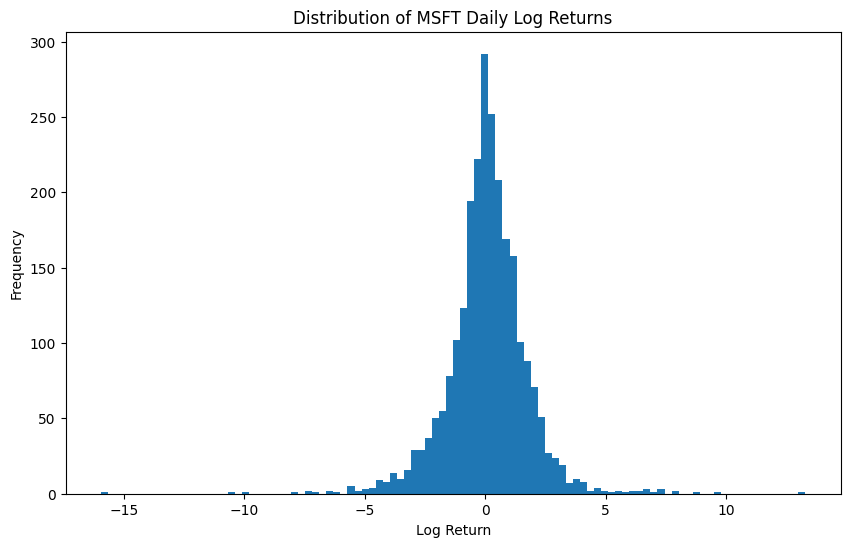

In [13]:
MSFT_return_data = data_pipe.fetch_returns_data('MSFT')
mean = MSFT_return_data["log_return"].mean()
variance = MSFT_return_data["log_return"].var()
st_dev = MSFT_return_data["log_return"].std()
print(f"Mean log return in observation period: {mean},\n"
      f"Variance of log returns in observation period: {variance},\n"
      f"Standard deviation of log returns in observation period: {st_dev}")


create_histogram_distribution_daily_log_returns('MSFT')

In [9]:
MSFT_return_data["log_return"].describe()

count    2513.000000
mean        0.000852
std         0.016933
min        -0.159453
25%        -0.006650
50%         0.001038
75%         0.009545
max         0.132929
Name: log_return, dtype: float64

### Covariance Matrix of Stock Returns ###

$$ X =
\begin{bmatrix}
r_{1,1} & r_{2,1} \\
r_{1,2} & r_{2,2} \\
\vdots  & \vdots  \\
r_{1,n} & r_{2,n}
\end{bmatrix} $$


$$ \Sigma = \frac{1}{n-1}(X - \bar{X})^\top (X - \bar{X}) $$

In [16]:
returns_df =  data_pipe.build_returns_df(tickers)

print(returns_df)

cov_matrix = returns_df.cov()
print(cov_matrix)

eigenvalues = np.linalg.eigvals(cov_matrix)
print(eigenvalues)

                AAPL      NVDA      MSFT       JNJ       BAC        VZ  \
Date                                                                     
2016-02-25  0.006844  0.002198  0.014305  0.013438  0.015542  0.005690   
2016-02-26  0.001549 -0.006607 -0.015474 -0.005656  0.030378 -0.001762   
2016-02-29 -0.002273 -0.006516 -0.008221 -0.005403 -0.014275 -0.005700   
2016-03-01  0.038946  0.043370  0.032866  0.018925  0.052131  0.014288   
2016-03-02  0.002186  0.005784  0.007013 -0.001680  0.020340  0.012744   
...              ...       ...       ...       ...       ...       ...   
2026-02-17  0.031177  0.011746 -0.011176 -0.000493  0.003609 -0.001634   
2026-02-18  0.001780  0.016142  0.006880  0.006799  0.011687 -0.018149   
2026-02-19 -0.014364 -0.000426 -0.000577  0.007806 -0.011119  0.012204   
2026-02-20  0.015234  0.010166 -0.003092 -0.018063  0.005481  0.012463   
2026-02-23  0.006029  0.009073 -0.032650  0.013720 -0.038226  0.008693   

                 WMT       UPS       

### Correlation (Normalized Covariance) ###

$$ \rho_{ij} = \frac{\mathrm{Cov}_{ij}}{\sigma_i \sigma_j} $$

In [20]:
corr_matrix = returns_df.corr()
print(corr_matrix)

          AAPL      NVDA      MSFT       JNJ       BAC        VZ       WMT  \
AAPL  1.000000  0.540873  0.661121  0.301358  0.416819  0.202343  0.314888   
NVDA  0.540873  1.000000  0.615399  0.106787  0.327764  0.050602  0.203226   
MSFT  0.661121  0.615399  1.000000  0.301775  0.410829  0.193823  0.315049   
JNJ   0.301358  0.106787  0.301775  1.000000  0.312671  0.384065  0.324196   
BAC   0.416819  0.327764  0.410829  0.312671  1.000000  0.288125  0.240327   
VZ    0.202343  0.050602  0.193823  0.384065  0.288125  1.000000  0.275498   
WMT   0.314888  0.203226  0.315049  0.324196  0.240327  0.275498  1.000000   
UPS   0.424544  0.321213  0.395744  0.303415  0.437017  0.262801  0.281571   
PFE   0.286495  0.143179  0.287056  0.506754  0.319355  0.328887  0.240093   
JPM   0.415144  0.337189  0.423918  0.336483  0.883003  0.283665  0.239492   

           UPS       PFE       JPM  
AAPL  0.424544  0.286495  0.415144  
NVDA  0.321213  0.143179  0.337189  
MSFT  0.395744  0.287056  0.42

### Let us plot the correlation matrix ###

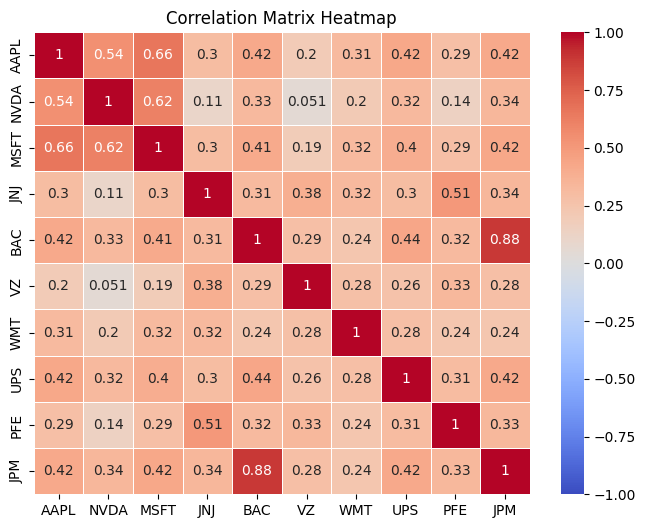

In [21]:
create_correlation_heatmap(corr_matrix)

### Set up an optimal portfolio simulation calculation ###

In [22]:
close_price_df = data_pipe.build_close_price_df(tickers)

close_price_df.head()

,AAPL,NVDA,MSFT,JNJ,BAC,VZ,WMT,UPS,PFE,JPM
Date,,,,,,,,,,
2016-02-24,21.764772,0.776172,45.191105,80.146530,9.742740,30.009754,18.647371,66.801430,18.383547,42.929043
2016-02-25,21.914251,0.777880,45.842216,81.230843,9.895348,30.180996,18.902964,67.387558,18.732599,43.594315
2016-02-26,21.948227,0.772757,45.138302,80.772697,10.200562,30.127850,18.477903,67.194481,18.512146,43.999588
2016-02-29,21.898397,0.767738,44.768753,80.337440,10.055987,29.956602,18.430672,66.580750,18.169210,43.051395
2016-03-01,22.768082,0.801768,46.264557,81.872269,10.594125,30.387684,18.464014,67.828896,18.395790,45.268959


In [ ]:
sim_runs = 10000
initial_investment = 1000000
n = len(close_price_df.columns)
print(n)

# I will set up placeholders to store all outputs of the simulation calculation:
weights_runs = np.zeros((sim_runs, n))
sharpe_ratio_runs = np.zeros(sim_runs)
expected_portfolio_returns_runs = np.zeros(sim_runs)
volatility_runs = np.zeros(sim_runs)
return_on_investment_runs = np.zeros(sim_runs)
final_value_runs = np.zeros(sim_runs)


## Run the calculations to obtain an efficient frontier and the optimal portfolio ##

In [ ]:
for i in range(sim_runs):
    # Generate random weights
    weights = p_sim.generate_portfolio_weights(n)
    # Store the weights
    weights_runs[i, :] = weights

    # Call "simulation_engine" function and store Sharpe ratio, return and volatility
    # Note that asset allocation is performed using the "asset_allocation" function
    expected_portfolio_returns_runs[i], volatility_runs[i], sharpe_ratio_runs[i], final_value_runs[i], \
    return_on_investment_runs[i] = p_sim.simulation_engine(close_price_df, weights, initial_investment)

    if i % 250 == 0:
        print(f"Simulation Run = {i}")
        print(f"Weights = {weights_runs[i].round(3)}, Final Value = ${final_value_runs[i]:.2f}, Sharpe Ratio = {sharpe_ratio_runs[i]:.5f}")
        print('\n')

### In this step, we extract the output data produced in the simulation calculation ###

- There is a problem - what if Sharpe Ratio is a negative?! #TODO

In [ ]:
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 
                           'Portfolio_Return': expected_portfolio_returns_runs.tolist(), 
                           'Sharpe_Ratio': sharpe_ratio_runs.tolist() })
print(sim_out_df)

max_sharpe_idx = sim_out_df["Sharpe_Ratio"].idxmax()
optimal_portfolio = sim_out_df.loc[max_sharpe_idx]
cloud_df = sim_out_df.drop(index=max_sharpe_idx)

print(optimal_portfolio)

### We will now plot the results and make some interesting observations ###

In [ ]:
fig = px.scatter(
    cloud_df,
    x="Volatility",
    y="Portfolio_Return",
    color="Sharpe_Ratio",
    size="Sharpe_Ratio",
    opacity=0.5,
    hover_data=["Sharpe_Ratio"]
)

fig.add_trace(go.Scatter(
    x=[optimal_portfolio["Volatility"]],
    y=[optimal_portfolio["Portfolio_Return"]],
    mode="markers+text",
    marker=dict(color="red", size=25, line=dict(color="orange", width=2)),
    name="Optimal Portfolio",
    text=["Optimal"],
    textposition="top left"
))

fig.update_layout(plot_bgcolor="white")
fig.show()

# Plot interactive plot for volatility
fig = px.line(sim_out_df, y = 'Volatility')
fig.show()

# Plot interactive plot for Portfolio Return
fig = px.line(sim_out_df, y = 'Portfolio_Return')
fig.update_traces(line_color = 'red')
fig.show()

# Plot interactive plot for Portfolio Return
fig = px.line(sim_out_df, y = 'Sharpe_Ratio')
fig.update_traces(line_color = 'purple')
fig.show()